
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---

# Trabajo práctico entregable - Parte 2

In [1]:
import io
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from statsmodels.stats.power import tt_ind_solve_power

sns.set_context("talk")


## Lectura del dataset

En la notebook 00 se explican los detalles generales de esta base.

En este trabajo se utiliza la versión procesada de la encuesta de Sysarmy 2026. Igual que en TP1, antes de aplicar herramientas inferenciales conviene organizar el análisis en etapas bien definidas:

1. cargar y reconocer el dataset,
2. definir la muestra de análisis,
3. justificar los criterios de limpieza,
4. describir los grupos seleccionados,
5. y recién después avanzar hacia estimación, test de hipótesis y comunicación.

Este orden ayuda a que la inferencia no aparezca como una caja negra, sino como la continuación natural de un análisis previamente justificado.


In [2]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)
df.head()


,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0
3,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),7800000.0,6000000.0,Cobro parte del salario en dólares,1470,3+ sueldos,Mix de las anteriores,No,...,NaN,NaN,NaN,60,Hombre Cis,Sí,NaN,True,Senior,7800000.0
4,Jujuy,Full-Time,Contractor,3500000.0,3200000.0,Cobro todo el salario en dólares,NaN,No,No recibo bono,No,...,NaN,NaN,NaN,29,Hombre Cis,Sí,Nose,True,Semi-Senior,3500000.0


### Exploración inicial

Como en TP1, conviene comenzar con una inspección breve de la base. Observar las primeras filas y las categorías disponibles permite verificar que la carga fue correcta y que las variables relevantes están efectivamente disponibles para el análisis.


In [3]:
df[:3]

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0


In [4]:
df.profile_gender.unique()

<StringArray>
[        'Mujer Cis',        'Hombre Cis', 'Prefiero no decir',
             'Trans',             'Queer',        'No binarie',
           'Agénero',                 nan]
Length: 8, dtype: str

## Preparación de la muestra

Antes de abordar los ejercicios formales, se construye la muestra sobre la que se realizará la inferencia. Igual que en TP1, esta etapa incluye:

- recodificación de variables,
- selección de casos relevantes,
- limpieza,
- y una exploración descriptiva inicial.

Este punto es central, porque la validez de la inferencia depende en gran medida de **sobre qué muestra** se está razonando.


### Recodificación de género

La consigna propone comparar dos grupos principales. Para volver la muestra más legible, la variable original de género se recodifica en categorías agrupadas y luego se seleccionan las dos de interés para la inferencia:

- **Varón cis**
- **Mujer cis**

Esta decisión no agota la diversidad de respuestas de la encuesta, pero sí permite definir con claridad los grupos A y B utilizados en el trabajo.


In [5]:
# Reagrupamos la variable de género para trabajar con categorías más limpias.
gender_map = {
    'Hombre Cis': 'Varón cis',
    'Mujer Cis': 'Mujer cis',
    'Queer': 'Diversidades',
    'Trans': 'Diversidades',
    'Lesbiana': 'Diversidades',
    'Agénero': 'Diversidades',
}

df = df.copy()
df.loc[:, 'profile_g'] = df.profile_gender.replace(gender_map)
df.profile_g.value_counts(dropna=False)


profile_g
Varón cis            3861
Mujer cis             983
Prefiero no decir      52
No binarie             22
Diversidades           20
NaN                     1
Name: count, dtype: int64

### Criterios de limpieza y procesamiento

Tomando TP1 como referencia, las decisiones de limpieza no se presentan como elecciones arbitrarias, sino como respuestas a una pregunta metodológica concreta:

> **¿sobre qué subconjunto observado queremos inferir la diferencia de salarios?**

En este trabajo, el parámetro de interés es la diferencia entre las medias poblacionales de salario neto mensual para los grupos **Varón cis** y **Mujer cis**. La muestra analizada se construye a partir de los casos observados que cumplen simultáneamente estas condiciones:

- pertenecer a uno de los dos grupos comparados;
- trabajar bajo modalidad **Full-Time**, para evitar mezclar salarios asociados a distintas cargas horarias;
- registrar un salario neto mensual dentro de un rango plausible;
- no quedar identificado como valor atípico según el criterio de **1.5 IQR**.

Estas decisiones buscan aumentar la comparabilidad entre grupos y reducir la influencia de observaciones extremas sobre la media, que es el estadístico central de los ejercicios 1 y 2.

Al mismo tiempo, conviene recordar que la encuesta es **observacional y voluntaria**. Por eso, incluso cuando se aplican herramientas de inferencia clásica, la generalización debe interpretarse con cautela: la muestra no equivale a una muestra aleatoria perfecta de todo el mercado laboral IT.


In [6]:
alpha = 0.05
salary_min = 300_000
salary_max = 20_000_000


In [7]:
# Igual que en TP1, dejamos explícito el criterio de limpieza.
# Nos quedamos con los dos grupos de interés, sólo Full-Time,
# y removemos valores absurdos + outliers por IQR.
analysis_df = df[['profile_g', 'salary_monthly_NETO', 'work_dedication']].copy()
analysis_df = analysis_df.dropna(subset=['profile_g', 'salary_monthly_NETO', 'work_dedication'])
analysis_df = analysis_df[analysis_df['profile_g'].isin(['Varón cis', 'Mujer cis'])]
analysis_df = analysis_df[analysis_df['work_dedication'] == 'Full-Time']
analysis_df = analysis_df[
    analysis_df['salary_monthly_NETO'].between(salary_min, salary_max)
]

Q1 = analysis_df['salary_monthly_NETO'].quantile(0.25)
Q3 = analysis_df['salary_monthly_NETO'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

analysis_df = analysis_df[
    analysis_df['salary_monthly_NETO'].between(lower_bound, upper_bound)
]

analysis_df['profile_g'].value_counts()


profile_g
Varón cis    3311
Mujer cis     856
Name: count, dtype: int64

### Construcción de los grupos de comparación

Una vez definida y limpiada la muestra, se separan los salarios netos correspondientes a los grupos A y B. Desde este punto, todo el análisis inferencial se apoya sobre estas dos muestras independientes.


In [8]:
groupA = analysis_df.loc[
    analysis_df['profile_g'] == 'Varón cis', 'salary_monthly_NETO'
].copy()

groupB = analysis_df.loc[
    analysis_df['profile_g'] == 'Mujer cis', 'salary_monthly_NETO'
].copy()

print(f"Tamaño de groupA (Varón cis): {len(groupA)}")
print(f"Tamaño de groupB (Mujer cis): {len(groupB)}")


Tamaño de groupA (Varón cis): 3311
Tamaño de groupB (Mujer cis): 856


### Exploración descriptiva de la muestra

Antes de pasar a la inferencia, conviene observar cómo quedan las distribuciones salariales después del filtrado.

Los histogramas permiten examinar la forma general de cada grupo, mientras que el boxplot resume:

- la posición central,
- la dispersión,
- y la posible asimetría.

Esta etapa es importante porque ayuda a interpretar luego el intervalo de confianza y el test de hipótesis: no se comparan números aislados, sino distribuciones con cierta variabilidad interna.


### Supuestos y alcance de la inferencia

Antes de estimar y testear, conviene explicitar tres ideas que en clase aparecen de manera recurrente.

1. **Independencia aproximada:** se trabaja tratando a las observaciones como aproximadamente independientes entre sí.
2. **Uso de Welch:** para comparar medias se elige el test t de Welch, porque no exige asumir igualdad de varianzas entre grupos.
3. **Tamaños muestrales grandes:** después de la limpieza ambos grupos conservan muchos casos, por lo que el Teorema Central del Límite ayuda a justificar la inferencia sobre medias.

Estas condiciones no vuelven “perfecto” el análisis, pero sí lo hacen más consistente con el marco teórico visto en las clases de estimación e hipótesis.


In [9]:
print(f"Mean: {groupA.mean():,.2f}")
print(f"Median: {groupA.median():,.2f}")
print(f"Standard Deviation: {groupA.std():,.2f}")


Mean: 3,051,476.29
Median: 2,800,000.00
Standard Deviation: 1,461,529.69


In [10]:
print(f"Mean: {groupB.mean():,.2f}")
print(f"Median: {groupB.median():,.2f}")
print(f"Standard Deviation: {groupB.std():,.2f}")


Mean: 2,673,102.63
Median: 2,400,000.00
Standard Deviation: 1,335,188.29


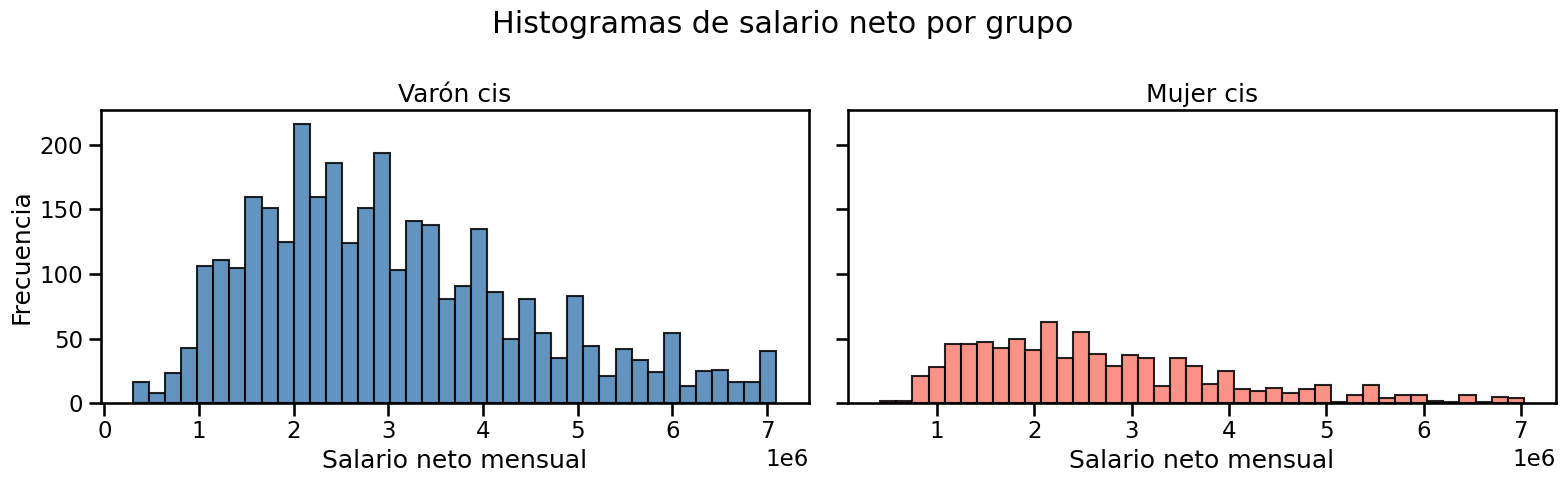

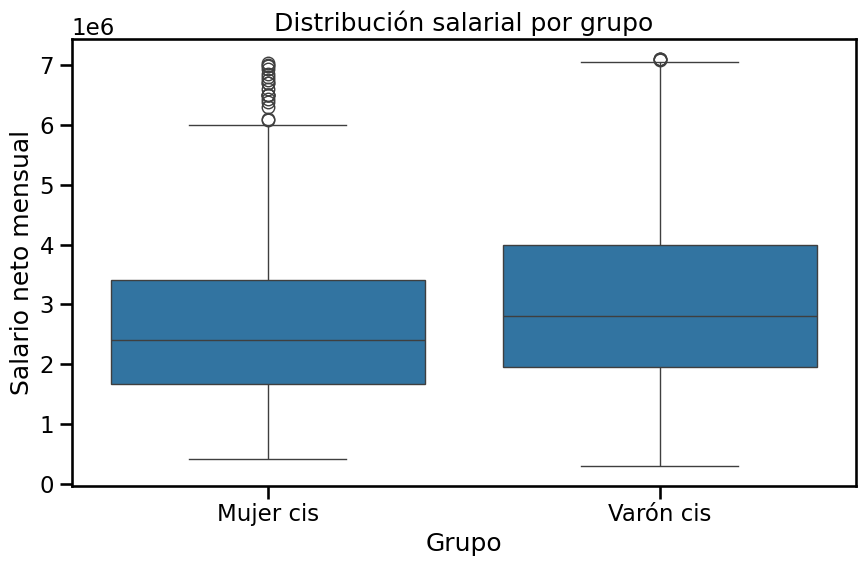

In [11]:
# Histogramas para comparar ambas distribuciones.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].hist(groupA, bins=40, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Varón cis')
axes[0].set_xlabel('Salario neto mensual')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(groupB, bins=40, color='salmon', edgecolor='black', alpha=0.85)
axes[1].set_title('Mujer cis')
axes[1].set_xlabel('Salario neto mensual')

plt.suptitle('Histogramas de salario neto por grupo')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=analysis_df, x='profile_g', y='salary_monthly_NETO', ax=ax)
ax.set_title('Distribución salarial por grupo')
ax.set_xlabel('Grupo')
ax.set_ylabel('Salario neto mensual')
plt.tight_layout()
plt.show()


## Ejercicio 1: Estimación

**Consigna:** Calcular una estimación puntual y un intervalo de confianza de nivel $(1-\alpha)$ para la resta entre la media del salario neto para Hombres y la media del salario neto para mujeres (diferencia entre el grupo A y el grupo B).

### ¿Qué significa estimar en este contexto?

En esta sección no interesa únicamente describir cuánto difieren los promedios en la muestra, sino aproximar una cantidad poblacional:

- $\mu_A$: media poblacional del salario neto del grupo A (**Varón cis**)
- $\mu_B$: media poblacional del salario neto del grupo B (**Mujer cis**)

La cantidad de interés es, por lo tanto:

$$\mu_A - \mu_B$$

Primero se calcula una **estimación puntual** (la diferencia entre medias muestrales) y luego un **intervalo de confianza del 95%**, que incorpora la incertidumbre asociada a la variabilidad muestral.


In [12]:
# Estimación puntual: diferencia entre medias muestrales.
mean_diff = groupA.mean() - groupB.mean()
varA = groupA.var(ddof=1)
varB = groupB.var(ddof=1)
nA = len(groupA)
nB = len(groupB)

# Error estándar de la diferencia de medias.
se_diff = math.sqrt(varA / nA + varB / nB)

# Grados de libertad aproximados de Welch-Satterthwaite.
welch_df = (varA / nA + varB / nB) ** 2 / (
    ((varA / nA) ** 2 / (nA - 1)) + ((varB / nB) ** 2 / (nB - 1))
)

t_crit = stats.t.ppf(1 - alpha / 2, df=welch_df)
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

print(f"Estimación puntual (mu_A - mu_B): {mean_diff:,.2f}")
print(f"IC 95% para (mu_A - mu_B): [{ci_low:,.2f}, {ci_high:,.2f}]")


Estimación puntual (mu_A - mu_B): 378,373.67
IC 95% para (mu_A - mu_B): [275,921.94, 480,825.40]


### Lectura de la magnitud práctica

La significancia estadística responde si la diferencia observada es compatible o no con la hipótesis nula. Sin embargo, también conviene preguntarse por su **magnitud sustantiva**.

Tomando como referencia el salario promedio del grupo **Mujer cis**, la diferencia estimada representa una proporción relevante de ese valor medio. En otras palabras: no solo aparece evidencia estadística de diferencia, sino que esa diferencia también resulta materialmente importante en la escala salarial del problema.


### Conclusión del ejercicio 1

Bajo el criterio de limpieza adoptado, la diferencia estimada entre medias es de aproximadamente **378 mil pesos mensuales** a favor del grupo **Varón cis**.

El intervalo de confianza del 95% se ubica aproximadamente entre **276 mil** y **481 mil pesos**, de modo que toda la banda queda del lado positivo. Esto sugiere que la diferencia observada no solo aparece en la muestra, sino que también se sostiene al incorporar incertidumbre muestral.


### Relación entre intervalo de confianza y test de hipótesis

Existe una relación directa entre ambos enfoques:

- si el intervalo de confianza del 95% para la diferencia de medias **incluye al cero**, entonces no habría evidencia suficiente para rechazar $H_0$ al 5%;
- si el intervalo **no incluye al cero**, entonces ese resultado es consistente con rechazar $H_0$ al mismo nivel.

En este caso, como el intervalo obtenido queda completamente por encima de cero, el resultado esperable es precisamente el rechazo de la hipótesis nula.


## Ejercicio 2: Test de hipótesis

En el ejercicio anterior se estimó una diferencia entre medias. Ahora se avanza un paso más: evaluar si la evidencia muestral es suficientemente fuerte como para rechazar la hipótesis de que esa diferencia poblacional es igual a cero.

La lógica del test es la siguiente:

1. formular una hipótesis nula,
2. medir qué tan compatible resulta la muestra con esa hipótesis,
3. usar el p-valor como criterio de decisión,
4. e interpretar el resultado en términos del problema original.


### 2.1 Formalización

Sea:

- $\mu_A$: media poblacional del salario neto de las personas del grupo A (**Varón cis**)
- $\mu_B$: media poblacional del salario neto de las personas del grupo B (**Mujer cis**)

Se quiere evaluar si ambas medias poblacionales son distintas. Por eso se plantea un test bilateral:

- **Hipótesis nula $H_0$**: $\mu_A - \mu_B = 0$
- **Hipótesis alternativa $H_1$**: $\mu_A - \mu_B \neq 0$

Se utiliza un **test t de Welch para dos muestras independientes**, porque:

1. los grupos son distintos,
2. interesa comparar medias,
3. y no se asume igualdad de varianzas.

El análisis se realiza con un nivel de significación $\alpha = 0.05$.


### 2.2 P-valor

Primero se calcula el estadístico de prueba y su p-valor asociado. Luego se compara ese p-valor con $\alpha = 0.05$ para decidir si corresponde rechazar o no la hipótesis nula.

En términos sustantivos, si se rechaza $H_0$, se concluye que la muestra ofrece evidencia estadística de que el salario promedio no es igual entre ambos grupos.

### Aclaración sobre variables confusoras

Esta comparación es **bivariada**: se relacionan salario neto y grupo de género sobre una muestra filtrada, pero **no se controlan explícitamente** otras variables que también pueden influir en el salario, por ejemplo:

- seniority,
- rol,
- años de experiencia,
- stack tecnológico,
- tamaño de empresa,
- modalidad de contratación.

Por eso, el resultado debe interpretarse como una **diferencia observada en la muestra analizada**, y no como una afirmación causal pura del tipo *"el género por sí solo explica exactamente esta brecha salarial"*.


In [13]:
# Test t de Welch para dos muestras independientes.
ttest = stats.ttest_ind(groupA, groupB, equal_var=False, alternative='two-sided')

print(f"Estadístico t: {ttest.statistic:,.4f}")
print(f"p-valor: {ttest.pvalue:,.10f}")

if ttest.pvalue < alpha:
    print(f"Como p-valor < {alpha}, rechazamos H0.")
    print("Hay evidencia estadística de que la media salarial difiere entre ambos grupos.")
else:
    print(f"Como p-valor >= {alpha}, no rechazamos H0.")
    print("No hay evidencia estadística suficiente para afirmar diferencia entre medias.")


Estadístico t: 7.2446
p-valor: 0.0000000000
Como p-valor < 0.05, rechazamos H0.
Hay evidencia estadística de que la media salarial difiere entre ambos grupos.


### 2.3 Interpretación previa del tamaño muestral

Antes de discutir la potencia, conviene notar que, después de la limpieza, ambos grupos conservan un tamaño considerable. Eso vuelve más estable la estimación de las medias y hace razonable aplicar herramientas como el test t de Welch.

De todos modos, una muestra grande no vuelve automáticamente causal a la interpretación: mejora la precisión estadística, pero no elimina por sí sola la posibilidad de variables confusoras.


### [Opcional] 2.4 Potencia del test

La potencia del test responde a la siguiente pregunta:

> si realmente existe una diferencia entre medias, ¿qué probabilidad tenía esta muestra de detectarla?

Para estandarizar la diferencia observada se usa **Cohen's d**, calculado con el **desvío combinado** de ambos grupos. Esta es una referencia más estándar que tomar la dispersión de un solo grupo. Además, se reporta **Hedges' g** como corrección por sesgo muestral, aunque en esta muestra grande ambas medidas resultan casi idénticas.

Como el contraste principal se hace con Welch, esta potencia debe leerse como una **aproximación práctica** basada en el tamaño de efecto estandarizado, no como una equivalencia exacta perfecta entre todas las variantes posibles del test.

Si la potencia es alta, entonces es menos probable que estemos frente a un escenario del tipo *"no detectamos una diferencia porque la muestra era demasiado chica"*.


In [14]:
pooled_std = math.sqrt(
    ((nA - 1) * varA + (nB - 1) * varB) / (nA + nB - 2)
)
cohen_d = mean_diff / pooled_std
hedges_g = cohen_d * (1 - 3 / (4 * (nA + nB) - 9))
ratio = len(groupB) / len(groupA)
power_target = 0.80

required_n_groupA = tt_ind_solve_power(
    effect_size=cohen_d,
    alpha=alpha,
    power=power_target,
    ratio=ratio,
    alternative='two-sided',
)

print(f"Desvío combinado (pooled std): {pooled_std:,.2f}")
print(f"Cohen's d: {cohen_d:,.4f}")
print(f"Hedges' g: {hedges_g:,.4f}")
print(f"Ratio n_B / n_A: {ratio:,.4f}")
print(f"n requerido en groupA para potencia 0.80: {required_n_groupA:,.2f}")
print(f"n observado en groupA: {len(groupA)}")


Desvío combinado (pooled std): 1,436,500.75
Cohen's d: 0.2634
Hedges' g: 0.2634
Ratio n_B / n_A: 0.2585
n requerido en groupA para potencia 0.80: 552.24
n observado en groupA: 3311


In [15]:
# Aproximamos la potencia observada por simulación Monte Carlo.
rng = np.random.default_rng(42)
n_sim = 2000
rejections = 0

for _ in range(n_sim):
    sim_A = rng.normal(loc=groupA.mean(), scale=groupA.std(ddof=1), size=len(groupA))
    sim_B = rng.normal(loc=groupB.mean(), scale=groupB.std(ddof=1), size=len(groupB))
    sim_test = stats.ttest_ind(sim_A, sim_B, equal_var=False, alternative='two-sided')
    if sim_test.pvalue < alpha:
        rejections += 1

observed_power = rejections / n_sim
print(f"Potencia observada aproximada: {observed_power:,.4f}")

if len(groupA) > required_n_groupA:
    print("La muestra parece más que suficiente para detectar un efecto de este tamaño.")


Potencia observada aproximada: 1.0000
La muestra parece más que suficiente para detectar un efecto de este tamaño.


### 2.5 Chequeos de robustez

Para no depender de una sola herramienta, se agrega un contraste complementario. La idea es verificar si la señal principal persiste cuando se mira una medida menos sensible a extremos —la mediana— y cuando se utiliza un test no paramétrico.

Si la conclusión general se mantiene bajo estas variantes, el hallazgo gana solidez y deja de descansar exclusivamente en un único procedimiento paramétrico.


In [16]:
median_diff = groupA.median() - groupB.median()
mannwhitney = stats.mannwhitneyu(groupA, groupB, alternative='two-sided')

print(f"Diferencia de medianas (A - B): {median_diff:,.2f}")
print(f"Mann-Whitney U: {mannwhitney.statistic:,.2f}")
print(f"p-valor Mann-Whitney: {mannwhitney.pvalue:,.10f}")


Diferencia de medianas (A - B): 400,000.00
Mann-Whitney U: 1,640,879.50
p-valor Mann-Whitney: 0.0000000000


### Conclusión del ejercicio 2

El test de Welch arroja un **p-valor extremadamente pequeño**, por lo que se rechaza la hipótesis nula de igualdad de medias al nivel $\alpha = 0.05$.

Además, este resultado es coherente con el ejercicio 1: como el intervalo de confianza del 95% para la diferencia de medias **no contiene al cero**, ambas herramientas apuntan en la misma dirección.

Los chequeos de robustez también acompañan esta lectura: la diferencia entre medianas sigue siendo positiva y el contraste no paramétrico vuelve a indicar una diferencia estadísticamente detectable entre grupos. Por lo tanto, la conclusión principal no depende solo de un único test ni de una única forma de resumir el salario.


## Ejercicio 3: Comunicación y visualización

**Consigna:** Seleccionar un resultado que parezca relevante a partir de alguno de los ejercicios del entregable y diseñar una comunicación basada en ese mensaje, en un archivo html.

### Mensaje elegido

El resultado elegido para comunicar es el siguiente:

> En la muestra analizada de trabajadores **Full-Time**, el salario neto promedio de **Varón cis** supera al de **Mujer cis**. La diferencia estimada ronda los **378 mil pesos mensuales**, con un intervalo de confianza del 95% entre aproximadamente **276 mil** y **481 mil pesos**.

Este mensaje fue elegido porque reúne en una sola pieza tres elementos centrales:

- la **dirección** del efecto,
- su **magnitud aproximada**,
- y la **incertidumbre** asociada a la estimación.

En lugar de acumular muchas estadísticas al mismo tiempo, el gráfico se concentra en una sola idea fuerte: cuánto vale la diferencia estimada y si el intervalo de confianza contiene o no al cero.


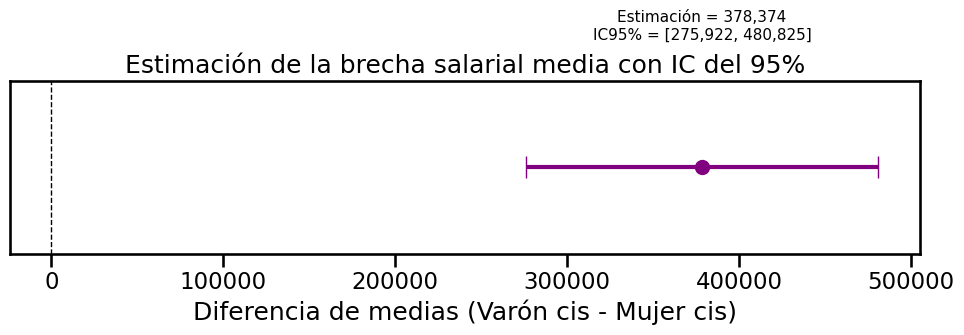

Interpretación: el intervalo de confianza no contiene al 0,
por lo que el gráfico comunica visualmente una diferencia positiva entre medias.


In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(
    x=mean_diff,
    y=0,
    xerr=[[mean_diff - ci_low], [ci_high - mean_diff]],
    fmt='o',
    color='purple',
    ecolor='purple',
    elinewidth=3,
    capsize=8,
    markersize=10,
)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks([])
ax.set_xlabel('Diferencia de medias (Varón cis - Mujer cis)')
ax.set_title('Estimación de la brecha salarial media con IC del 95%')
ax.text(
    mean_diff,
    0.08,
    f"Estimación = {mean_diff:,.0f}\nIC95% = [{ci_low:,.0f}, {ci_high:,.0f}]",
    ha='center',
    va='bottom',
    fontsize=11,
)
plt.tight_layout()
plt.show()

print('Interpretación: el intervalo de confianza no contiene al 0,')
print('por lo que el gráfico comunica visualmente una diferencia positiva entre medias.')


### Interpretación del gráfico

El punto central representa la **estimación puntual** de la diferencia de medias. La barra horizontal muestra el **intervalo de confianza del 95%**.

La clave visual es que todo el intervalo queda del lado positivo del eje horizontal. Eso resume de forma sintética dos ideas del trabajo:

- la diferencia estimada favorece al grupo **Varón cis**;
- incluso incorporando incertidumbre muestral, la brecha sigue siendo positiva.

Además, el gráfico ayuda a comunicar la **magnitud práctica** del resultado: no se trata solo de una diferencia estadísticamente significativa, sino también de una brecha relevante en la escala de salarios observada.


### Alcance poblacional y sesgos de selección

Además de los posibles confusores, conviene distinguir un segundo límite del análisis: la **representatividad** de la encuesta.

En este caso, la fuente de datos es una encuesta **voluntaria** y **autoadministrada**. Eso abre al menos tres cautelas:

- **autoselección:** responde quien decide participar, lo que puede sobrerrepresentar ciertos perfiles;
- **subcobertura:** algunos segmentos del mercado IT pueden quedar menos presentes que otros;
- **autorreporte:** salario, rol o dedicación dependen de lo que cada persona declara.

Por eso, la inferencia clásica sirve para cuantificar incertidumbre dentro de la muestra analizada, pero no garantiza por sí sola una extrapolación perfecta a toda la población laboral.


## Conclusión general

El trabajo sigue una secuencia similar a TP1: primero define la muestra, luego justifica la limpieza, después describe los datos y finalmente aplica herramientas inferenciales y de comunicación.

En esta muestra filtrada de personas **Full-Time**, se estima una diferencia positiva entre los salarios netos medios de los grupos **Varón cis** y **Mujer cis**. Esa diferencia se mantiene tanto en el intervalo de confianza como en el test de hipótesis y, además, conserva el mismo sentido cuando se realizan chequeos de robustez con medianas y con un contraste no paramétrico.

Al mismo tiempo, la interpretación debe hacerse con prudencia. El análisis es **bivariado**, por lo que no controla explícitamente seniority, experiencia, rol, stack u otras variables potencialmente relevantes. Además, la encuesta es **observacional y voluntaria**, con posibles efectos de autoselección, subcobertura y autorreporte, de modo que la representatividad poblacional no está garantizada en sentido estricto.

En síntesis, el trabajo aporta evidencia consistente de una brecha salarial media en la muestra analizada, la cuantifica con incertidumbre explícita, la contrasta con medidas de robustez y la comunica mediante una visualización centrada en un mensaje claro y verificable.
